In [ ]:
%matplotlib ipympl

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

wp_target = 24.5e9  # Target plasma frequency in Hz

Cc_values   = np.linspace(0.2e-15, 2.0e-15, 50)
Area_values = np.linspace(0.2,      2.0,     50)   # µm²
N_values    = np.arange(60, 160+1, 5)

# TODO reproduce

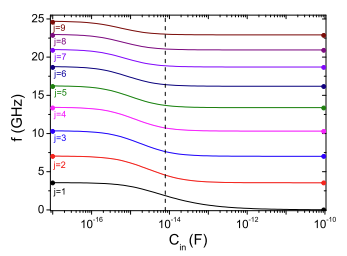


Optimal point for slice: Cc vs Area, N=60
Cc = 2e-15
Area_um2 = 0.2
f0 = 13.499  GHz
f1 = 21.104  GHz
f2 = 23.053  GHz
Score = -82.794



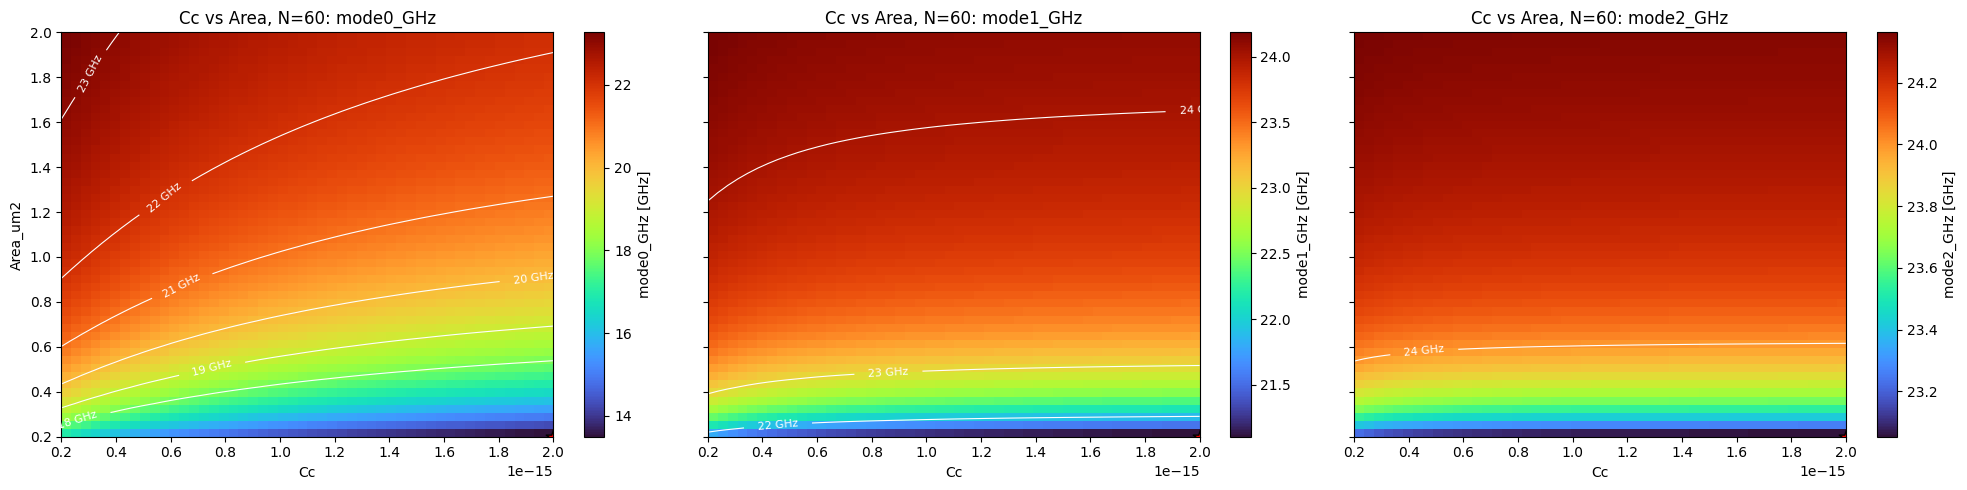


Optimal point for slice: Cc vs Area, N=110
Cc = 2e-15
Area_um2 = 0.273469387755102
f0 = 10.301  GHz
f1 = 18.184  GHz
f2 = 21.399  GHz
Score = -83.978



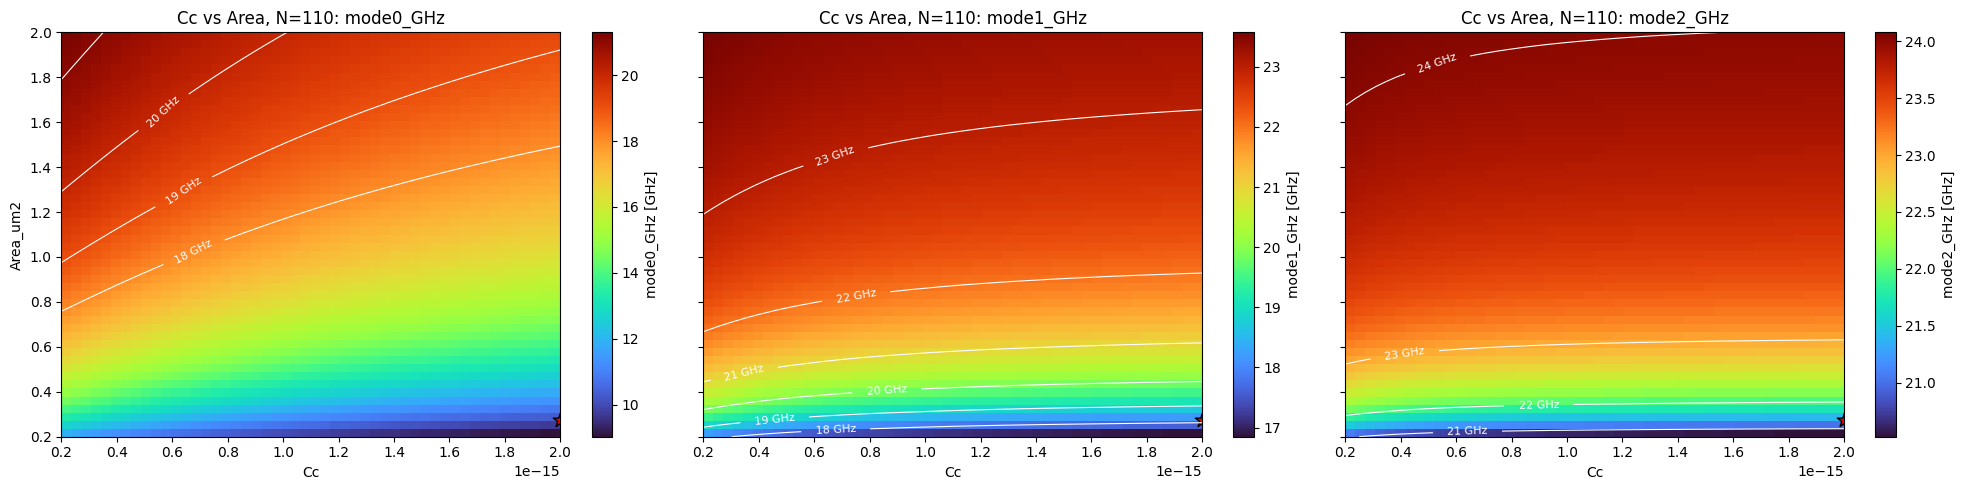


Optimal point for slice: Cc vs Area, N=160
Cc = 2e-15
Area_um2 = 0.5673469387755102
f0 = 10.787  GHz
f1 = 18.262  GHz
f2 = 21.395  GHz
Score = -80.144



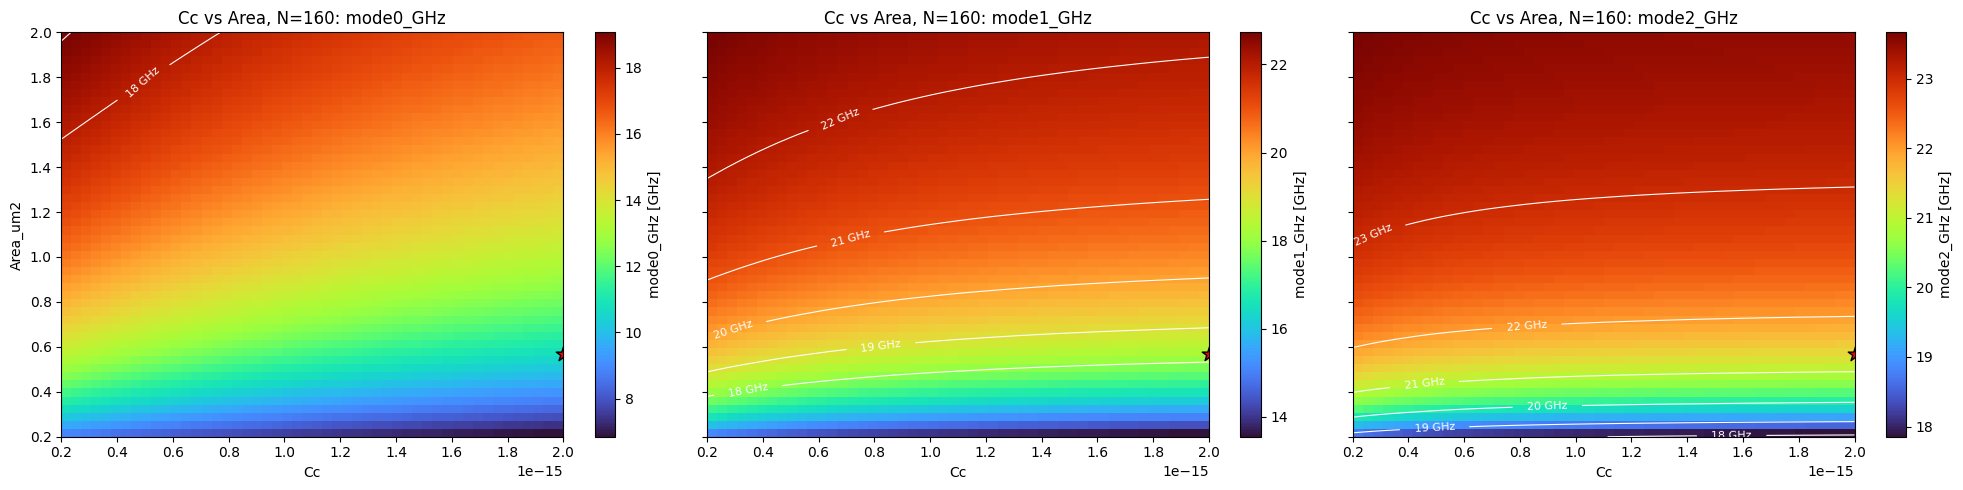


Optimal point for slice: Cc vs N, Area=0.2 µm²
Cc = 2e-15
N = 80
f0 = 11.251  GHz
f1 = 19.335  GHz
f2 = 22.111  GHz
Score = -86.457



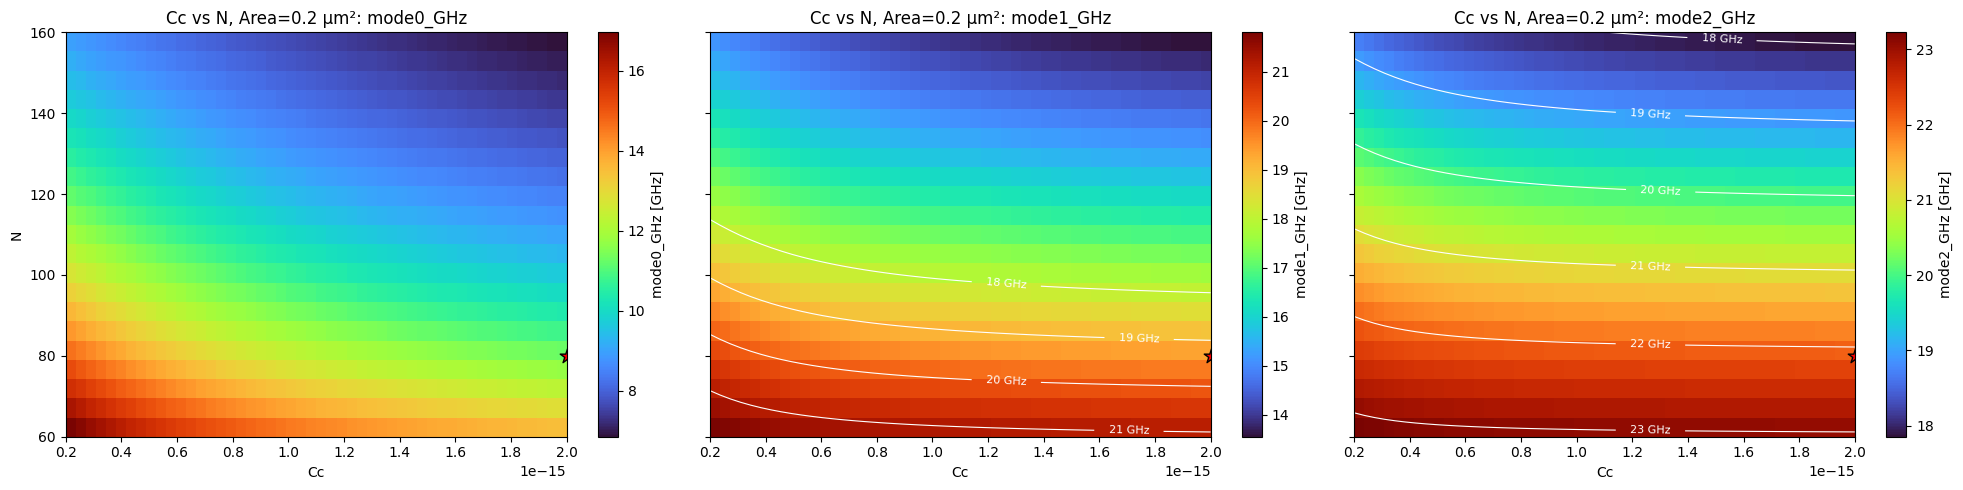


Optimal point for slice: Cc vs N, Area=1.1183673469387756 µm²
Cc = 2e-15
N = 160
f0 = 13.893  GHz
f1 = 20.664  GHz
f2 = 22.768  GHz
Score = -74.651



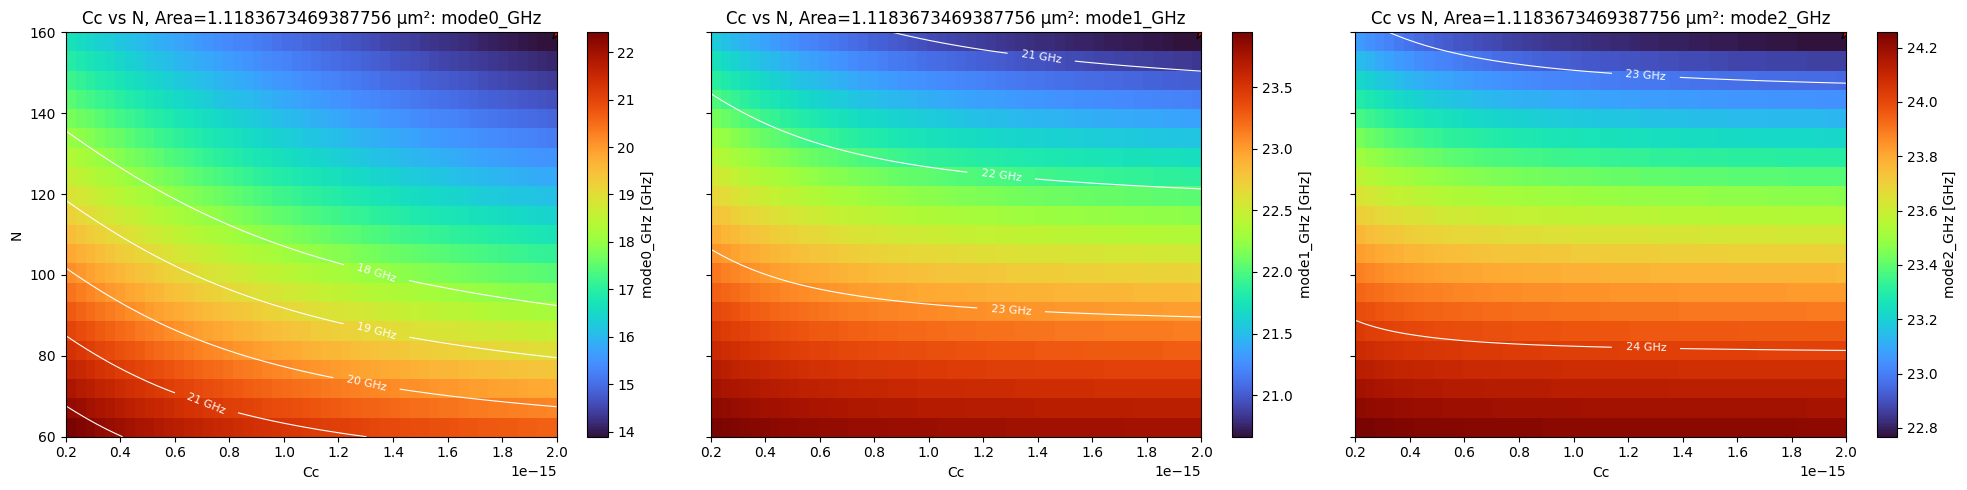


Optimal point for slice: Cc vs N, Area=2.0 µm²
Cc = 2e-15
N = 160
f0 = 16.595  GHz
f1 = 22.119  GHz
f2 = 23.485  GHz
Score = -63.539



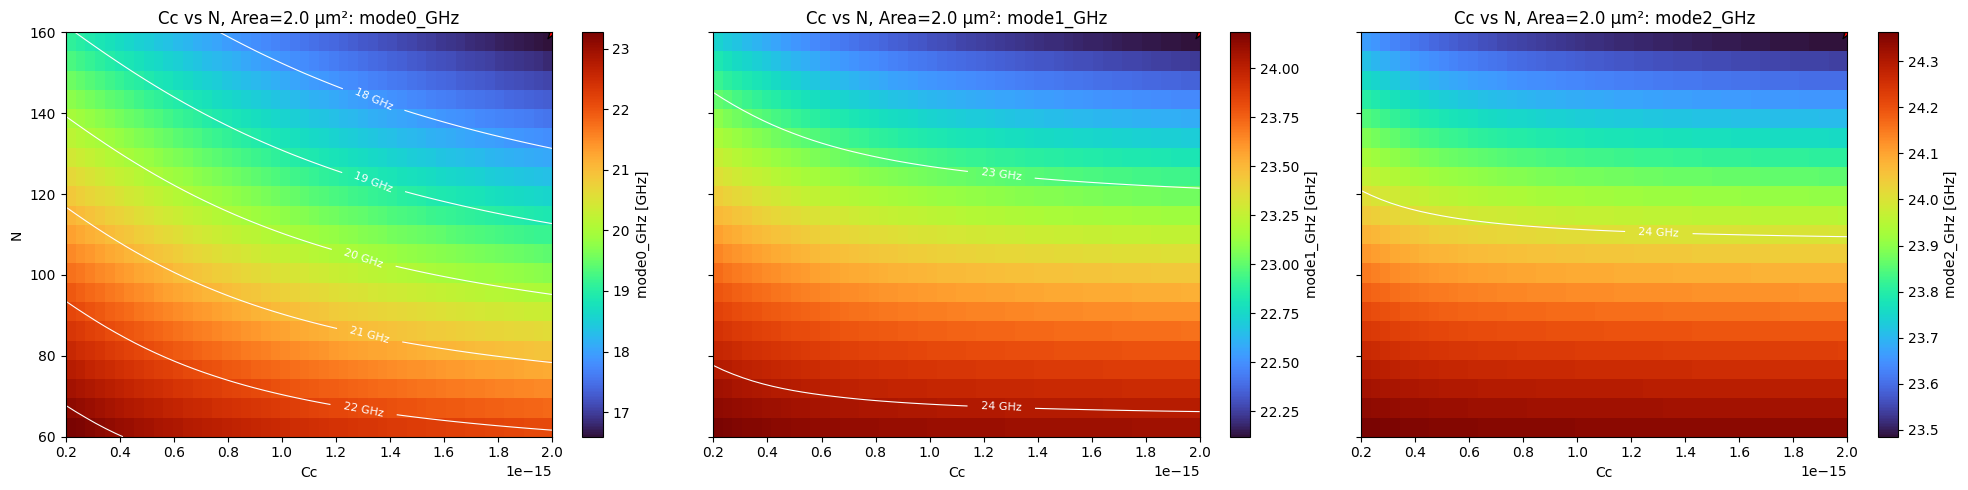


Optimal point for slice: Area vs N, Cc=2e-16 F
Area_um2 = 0.2
N = 115
f0 = 11.539  GHz
f1 = 17.913  GHz
f2 = 20.832  GHz
Score = -69.511



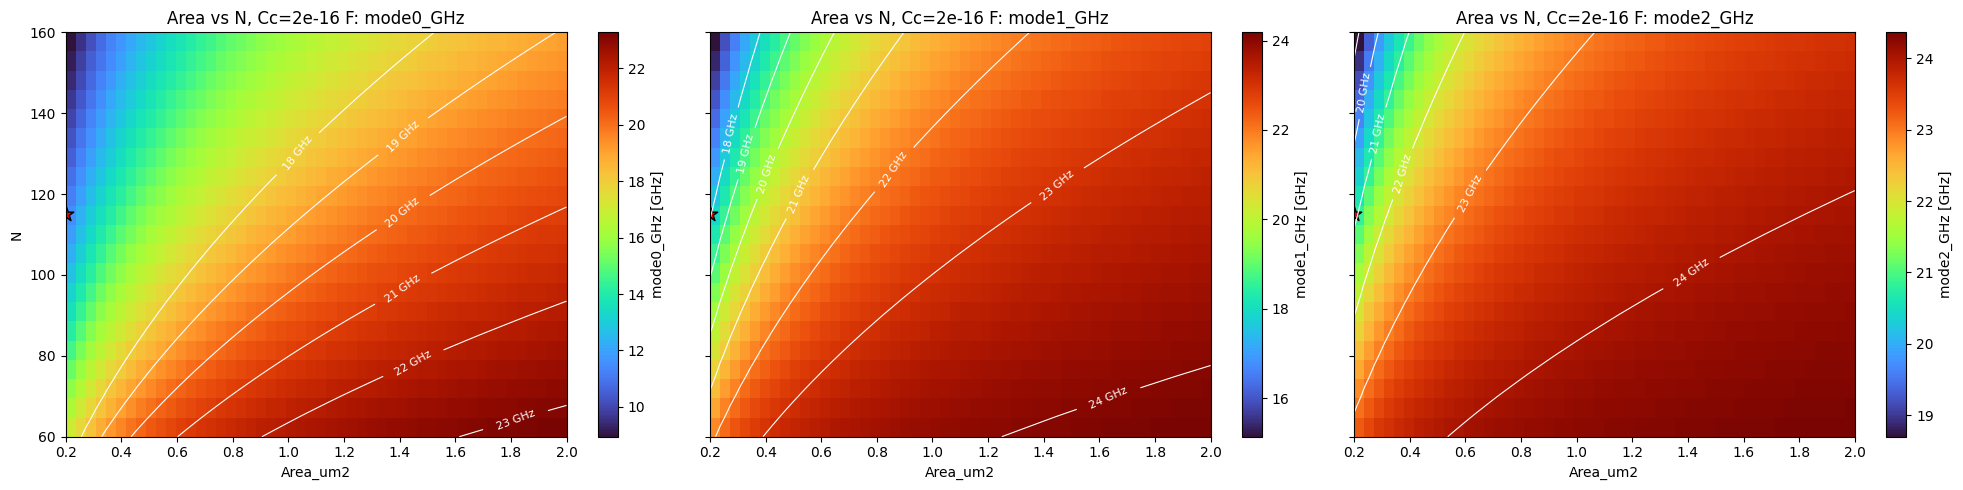


Optimal point for slice: Area vs N, Cc=1.1183673469387753e-15 F
Area_um2 = 0.2
N = 115
f0 = 11.539  GHz
f1 = 17.913  GHz
f2 = 20.832  GHz
Score = -69.511



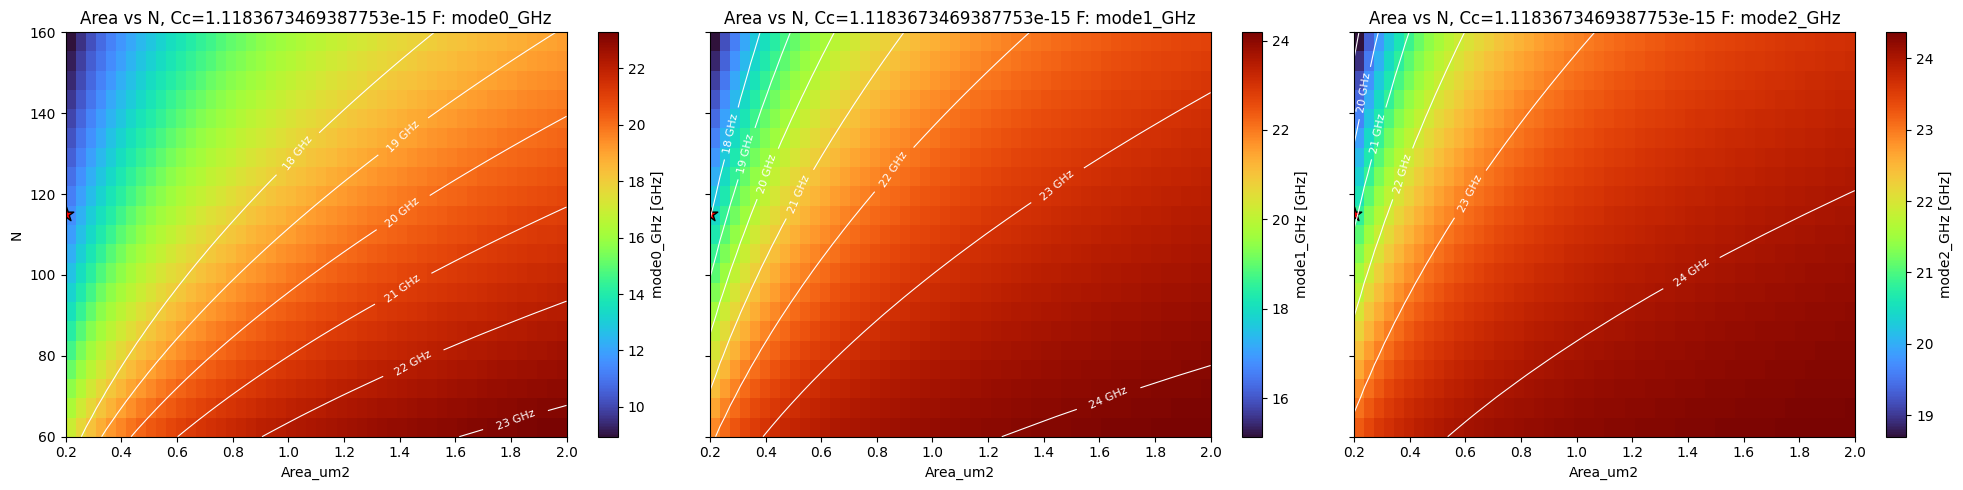


Optimal point for slice: Area vs N, Cc=2e-15 F
Area_um2 = 0.2
N = 115
f0 = 11.539  GHz
f1 = 17.913  GHz
f2 = 20.832  GHz
Score = -69.511



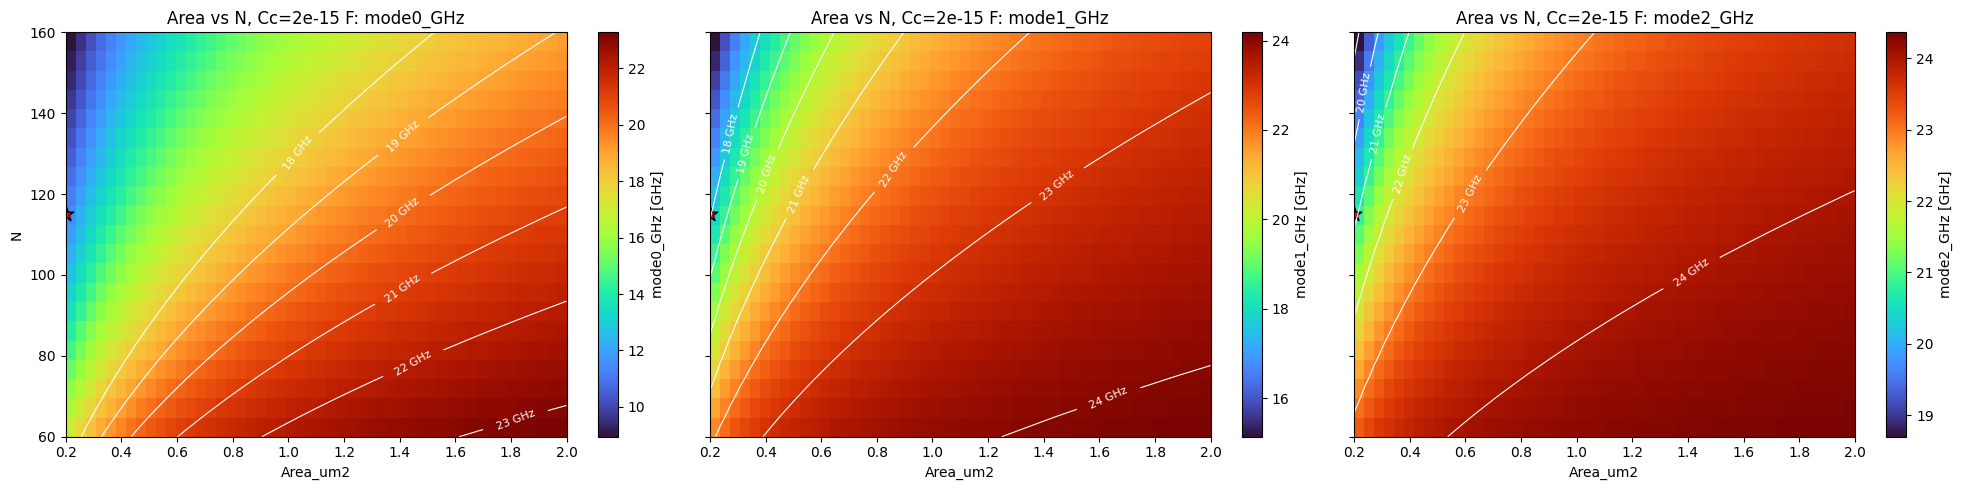

In [2]:
###############################################################################
# LOAD RESULTS INTO MEMORY FOR COLORMAPS
###############################################################################

all_results = []
for N in N_values:
    dfN = pd.read_csv(f"sweep_results_N{N}.csv")
    all_results.append(dfN)
full_df = pd.concat(all_results).reset_index(drop=True)


###############################################################################
# COLORMAP FUNCTIONS
###############################################################################

def plot_three_modes(df_subset, x, y, modes, title_prefix,
                     contour_levels=[18, 19, 20, 21, 22, 23, 24],
                     f_target=wp_target/1e9,   # GHz
                    w0=10, w01=10.0, w12=0.0, wT=0.0):
    """
    df_subset : DataFrame slice
    x, y      : parameter names ('Cc', 'Area_um2', 'N')
    modes     : ['mode0_GHz', 'mode1_GHz', 'mode2_GHz']
    """

    X = np.unique(df_subset[x])
    Y = np.unique(df_subset[y])

    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

    # Containers for grids
    Zgrids = []

    # ---------------------------
    # Build all 3 Z-grids first
    # ---------------------------
    for mode in modes:
        Z = np.empty((len(Y), len(X)))

        for i, yy in enumerate(Y):
            for j, xx in enumerate(X):
                val = df_subset[(df_subset[x] == xx) & (df_subset[y] == yy)][mode].values
                Z[i, j] = val[0] if len(val) > 0 else np.nan

        Zgrids.append(Z)

    Z0, Z1, Z2 = Zgrids   # mode0, mode1, mode2 grids

    # ---------------------------
    # Find optimal point
    # ---------------------------

    score = np.full_like(Z0, np.nan)

    for i in range(len(Y)):
        for j in range(len(X)):
            f0, f1, f2 = Z0[i,j], Z1[i,j], Z2[i,j]
            if np.isnan(f0) or np.isnan(f1) or np.isnan(f2):
                continue

            # criteria
            d01 = abs(f1 - f0)       # want large
            d12 = abs(f2 - f1)       # want small
            dT  = abs(f1 - f_target) + abs(f2 - f_target)   # want small

            score[i,j] = (
                -w0 * f0/20 +
                w01 * (-d01) +     # maximize f1-f0
                w12 * (d12)  +     # minimize |f2-f1|
                wT  * (dT)         # minimize |fi - target|
            )

    # find minimal score
    idx = np.nanargmin(score)
    i_best = idx // len(X)
    j_best = idx %  len(X)

    x_best = X[j_best]
    y_best = Y[i_best]

    f0_best = Z0[i_best, j_best]
    f1_best = Z1[i_best, j_best]
    f2_best = Z2[i_best, j_best]

    print("\n============================")
    print(f"Optimal point for slice: {title_prefix}")
    print(f"{x} = {x_best}")
    print(f"{y} = {y_best}")
    print(f"f0 = {f0_best:.3f}  GHz")
    print(f"f1 = {f1_best:.3f}  GHz")
    print(f"f2 = {f2_best:.3f}  GHz")
    print(f"Score = {score[i_best,j_best]:.3f}")
    print("============================\n")

    # ---------------------------
    # Plot all 3 subplots
    # ---------------------------
    for idx, mode in enumerate(modes):
        Z = Zgrids[idx]
        ax = axs[idx]

        im = ax.imshow(
            Z,
            aspect='auto',
            origin='lower',
            extent=[X[0], X[-1], Y[0], Y[-1]],
            cmap='turbo'
        )
        plt.colorbar(im, ax=ax, label=f"{mode} [GHz]")

        # Add contour lines
        XX, YY = np.meshgrid(X, Y)
        CS = ax.contour(XX, YY, Z, levels=contour_levels,
                        colors='white', linewidths=0.8)
        ax.clabel(CS, inline=True, fontsize=8, fmt='%d GHz')

        # Mark optimal point
        ax.scatter(x_best, y_best, s=120, c='red', marker='*', edgecolors='black', linewidths=1.0)

        ax.set_xlabel(x)
        if idx == 0:
            ax.set_ylabel(y)
        ax.set_title(f"{title_prefix}: {mode}")

    fig.tight_layout()
    plt.show()




###############################################################################
# 1) Cc vs Area for three N values (start/middle/end)
###############################################################################

Ns_for_maps = [N_values[0], N_values[len(N_values)//2], N_values[-1]]

for Nmap in Ns_for_maps:
    dfN = full_df[full_df["N"] == Nmap]

    plot_three_modes(
        df_subset=dfN,
        x="Cc",
        y="Area_um2",
        modes=["mode0_GHz", "mode1_GHz", "mode2_GHz"],
        title_prefix=f"Cc vs Area, N={Nmap}"
    )


###############################################################################
# 2) Cc vs N for three Area values (start/mid/end)
###############################################################################

Areas_for_maps = [Area_values[0], Area_values[len(Area_values)//2], Area_values[-1]]

for Amap in Areas_for_maps:
    dfA = full_df[np.isclose(full_df["Area_um2"], Amap)]

    plot_three_modes(
        df_subset=dfA,
        x="Cc",
        y="N",
        modes=["mode0_GHz", "mode1_GHz", "mode2_GHz"],
        title_prefix=f"Cc vs N, Area={Amap} µm²"
    )


###############################################################################
# 3) Area vs N for three Cc values (start/mid/end)
###############################################################################

Ccs_for_maps = [Cc_values[0], Cc_values[len(Cc_values)//2], Cc_values[-1]]

for Ccmap in Ccs_for_maps:
    dfC = full_df[np.isclose(full_df["Cc"], Ccmap)]

    plot_three_modes(
        df_subset=dfC,
        x="Area_um2",
        y="N",
        modes=["mode0_GHz", "mode1_GHz", "mode2_GHz"],
        title_prefix=f"Area vs N, Cc={Ccmap} F"
    )


In [2]:
modes_plain

array([-8.23126860e-05+1.18607190e+04j, -8.13894795e+05+1.42311494e+11j,
       -5.68973777e+04+1.73356967e+11j, -9.19949587e+03+1.81404235e+11j,
       -1.62643775e+03+1.84445257e+11j, -4.30214603e+02+1.85883641e+11j,
       -1.39088484e+02+1.86675553e+11j, -6.93679512e+01+1.87154442e+11j,
       -2.83494214e+01+1.87466946e+11j, -1.32911661e+01+1.87680823e+11j,
       -2.88866445e+00+1.87833490e+11j, -4.13865918e+00+1.87946577e+11j,
       -1.74638498e+00+1.88032259e+11j, -1.95261374e+00+1.88098966e+11j,
       -5.78262568e-01+1.88151969e+11j, -6.25452742e-01+1.88194410e+11j,
       -1.26353890e-01+1.88229279e+11j, -3.29115182e-01+1.88257872e+11j,
       -1.18059993e-01+1.88281953e+11j, -4.02575672e-01+1.88302365e+11j,
       -7.13147316e-03+1.88319524e+11j, -3.03775892e-02+1.88334310e+11j,
       -2.35621333e-02+1.88347185e+11j, -9.69076529e-03+1.88358353e+11j,
       -8.73634219e-03+1.88368103e+11j, -4.27925587e-03+1.88376672e+11j,
       -2.30503082e-03+1.88384162e+11j, -3.57627869

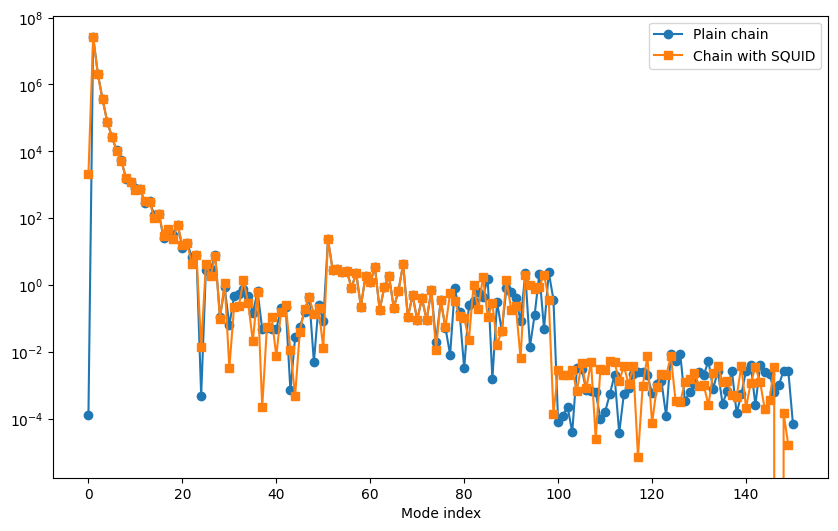

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

modes_plain = np.load("modes_plain.npy")
modes_squid = np.load("modes_squid.npy")
plt.figure(figsize=(10,6))
plt.plot(abs(modes_plain.real), 'o-', label='Plain chain')
plt.plot(abs(modes_squid.real), 's-', label='Chain with SQUID')
plt.yscale('log')
plt.xlabel('Mode index')
plt.legend()
plt.show()